# M1.Ex3: Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex3_class.ipynb)
- Dataset:`sklearn.datasets.load_iris()`

In [1]:
import pandas as pd
import sklearn

![Iris Flowers](https://github.com/HassanAlgoz/B5/blob/main/content/W3/M1/assets/iris_flowers.png?raw=1)

### Step 1.a Load the data

In [2]:
iris = sklearn.datasets.load_iris(as_frame=True)

### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = iris.data
y = iris.target

### Step 2.b print the type of each

In [4]:
print(f"Type of X: {type(X)}")
print(f"Type of y: {type(y)}")

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [5]:
print(f"Target Names: {iris.target_names}")
print("The task is: Classification")

Target Names: ['setosa' 'versicolor' 'virginica']
The task is: Classification


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
print(f"Number of samples (Rows) in X: {X.shape[0]}")
print(f"Number of features (Columns) in X: {X.shape[1]}")
print(f"Number of samples in target y: {y.shape[0]}")

Number of samples (Rows) in X: 150
Number of features (Columns) in X: 4
Number of samples in target y: 150


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [7]:
summary = X.describe()
print(summary)

print("\nMedian values for each feature:")
print(X.median())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

Median values for each feature:
sepal length (cm)    5.80
sepal width (cm)     3.00
petal length (cm)    4.35
petal width (cm)     1.30
dtype: float64


### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

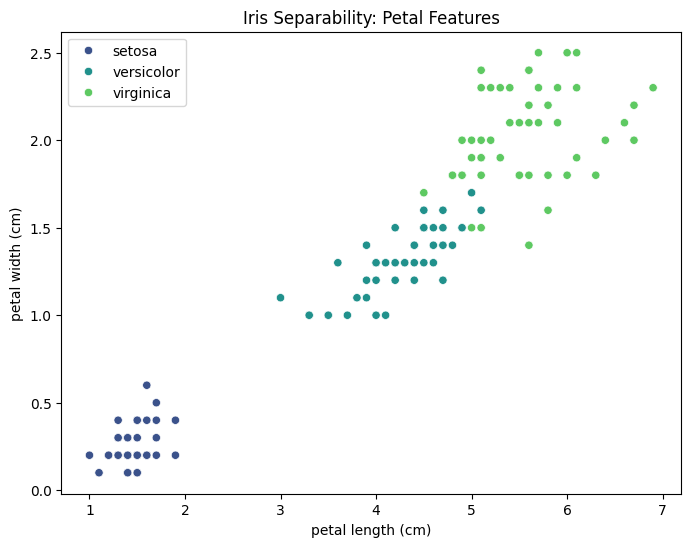

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X['petal length (cm)'], y=X['petal width (cm)'], hue=iris.target_names[y], palette='viridis')
plt.title('Iris Separability: Petal Features')
plt.show()

### Step 6. Keep the following in "Steps 7" onwards

1. First model will trian on the features: `sepal length (cm)` & `sepal width (cm)`
2. Second model will train on the features: `petal length (cm)` & `petal width (cm)`

Finally, evaluate and compare which of the two feature-sets scored better.

Let's do both subsets now..

### Step 6.a subset the features `sepal length (cm)` & `sepal width (cm)`


In [9]:
X_sepal = X[['sepal length (cm)', 'sepal width (cm)']]

### Step 6.b subset the features `petal length (cm)` & `petal width (cm)`


In [10]:
X_petal = X[['petal length (cm)', 'petal width (cm)']]

### Step 7. Initialize 2 `LogisticRegression` models

In [11]:
from sklearn.linear_model import LogisticRegression

model_sepal = LogisticRegression(max_iter=200)
model_petal = LogisticRegression(max_iter=200)

### Step 8. Split the dataset into train and test sets (remember to stratify by the target to account for class imbalance)

In [12]:
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train, y_test = train_test_split(X_sepal, y, test_size=0.2, random_state=42)

X_train_p, X_test_p, _, _ = train_test_split(X_petal, y, test_size=0.2, random_state=42)

### Step 9.a Train both models

In [13]:
model_sepal.fit(X_train_s, y_train)

model_petal.fit(X_train_p, y_train)

print("Both models have been trained.")

Both models have been trained.


### Step 10. Evaluate and compare both models

In [14]:
score_s = model_sepal.score(X_test_s, y_test)
score_p = model_petal.score(X_test_p, y_test)

print(f"Accuracy with Sepal features: {score_s:.2%}")
print(f"Accuracy with Petal features: {score_p:.2%}")

Accuracy with Sepal features: 90.00%
Accuracy with Petal features: 100.00%


### Step 11. Which of the two subset of features better distinguishes iris flowers? Can you easily tell?

In [ ]:
The Petal subset (length & width) is much better at distinguishing iris flowers
because the species are more clearly separated in that feature space.

### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

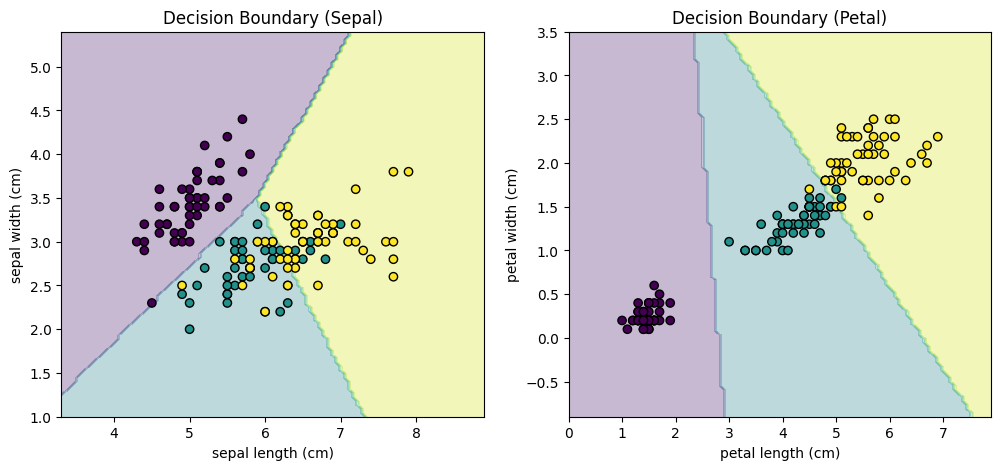

In [15]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

DecisionBoundaryDisplay.from_estimator(model_sepal, X_sepal, response_method="predict", ax=ax1, cmap='viridis', alpha=0.3)
ax1.scatter(X_sepal.iloc[:, 0], X_sepal.iloc[:, 1], c=y, edgecolor="k", cmap='viridis')
ax1.set_title("Decision Boundary (Sepal)")

DecisionBoundaryDisplay.from_estimator(model_petal, X_petal, response_method="predict", ax=ax2, cmap='viridis', alpha=0.3)
ax2.scatter(X_petal.iloc[:, 0], X_petal.iloc[:, 1], c=y, edgecolor="k", cmap='viridis')
ax2.set_title("Decision Boundary (Petal)")

plt.show()